In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import math

TensorFlow version: 2.19.0


In [2]:
datos, metadatos = tfds.load('cifar10', as_supervised=True, with_info=True)

CLASE_LIVIANO = 1  # automobile
CLASE_PESADO  = 9  # truck

nombres_clases = ['Liviano (Automóvil)', 'Pesado (Camión)']

print("Clases originales de CIFAR-10:")
print(metadatos.features['label'].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.JA8JUC_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.JA8JUC_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Clases originales de CIFAR-10:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
def filtrar_vehiculos(imagen, etiqueta):
    return tf.logical_or(
        tf.equal(etiqueta, CLASE_LIVIANO),
        tf.equal(etiqueta, CLASE_PESADO)
    )

def remap_etiquetas(imagen, etiqueta):
    nueva_etiqueta = tf.cast(tf.equal(etiqueta, CLASE_PESADO), tf.int64)
    return imagen, nueva_etiqueta

datos_entrenamiento_raw = datos['train'].filter(filtrar_vehiculos).map(remap_etiquetas)
datos_pruebas_raw       = datos['test'].filter(filtrar_vehiculos).map(remap_etiquetas)

print("Dataset filtrado: automobile vs truck")

Dataset filtrado: automobile vs truck


In [4]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255.0
    return imagenes, etiquetas

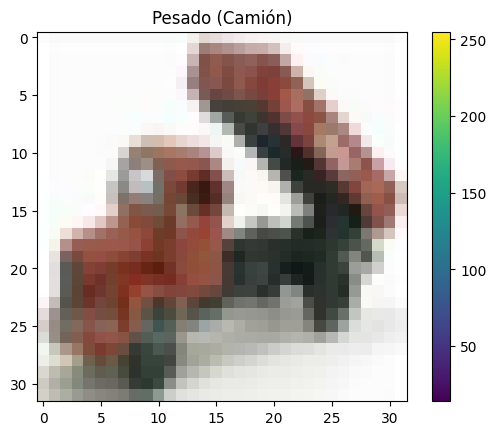

In [6]:
for imagen, etiqueta in datos_entrenamiento_raw.take(1):
    break

plt.figure()
plt.imshow(imagen.numpy())
plt.colorbar()
plt.grid(False)
plt.title(nombres_clases[etiqueta.numpy()])
plt.show()

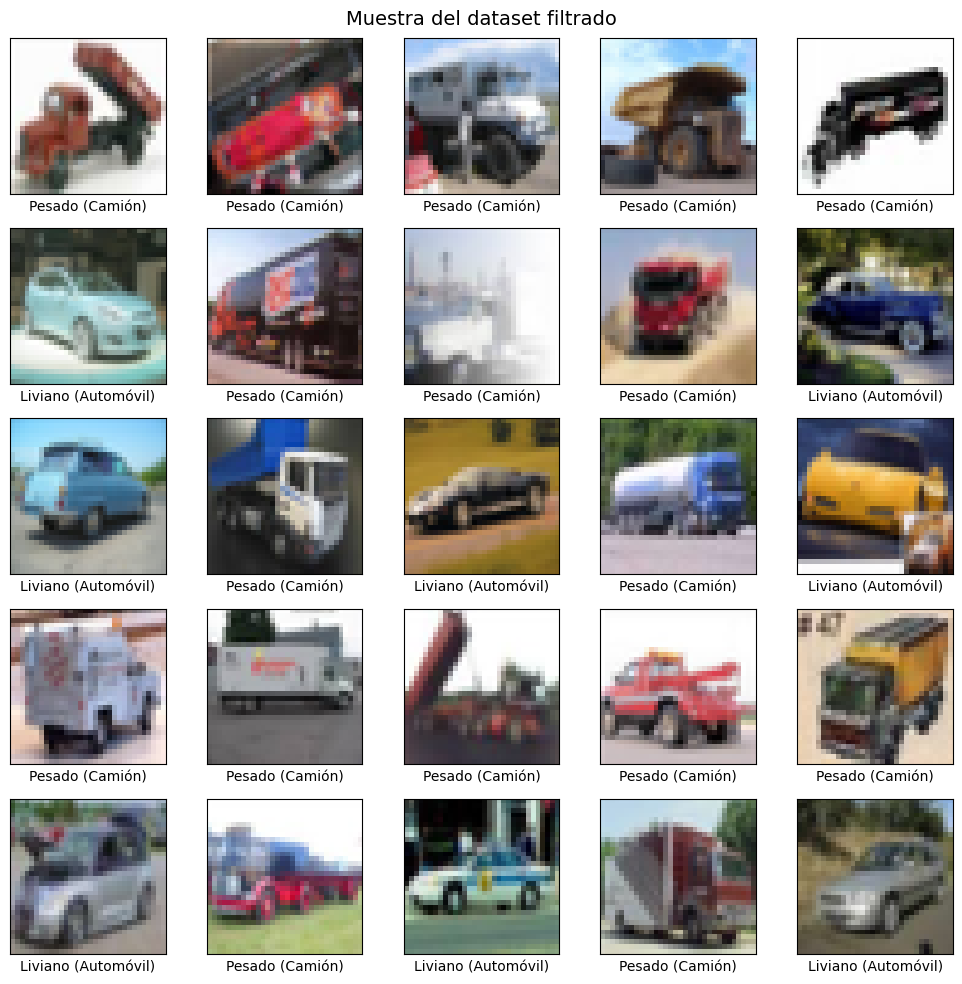

In [7]:
plt.figure(figsize=(10, 10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento_raw.take(25)):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen.numpy())
    plt.xlabel(nombres_clases[etiqueta.numpy()])
plt.suptitle("Muestra del dataset filtrado", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3), dtype=tf.float32),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(2, activation=tf.nn.softmax)
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,114 (1.56 MB)

 Trainable params: 410,114 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [10]:
ej_entrenamiento = 10000
ej_pruebas       = 2000
LOTE = 32

datos_entrenamiento = (
    datos_entrenamiento_raw
    .map(normalizar)
    .cache()
    .shuffle(ej_entrenamiento)
    .batch(LOTE)
    .repeat()
)

datos_pruebas = (
    datos_pruebas_raw
    .map(normalizar)
    .cache()
    .batch(LOTE)
)

In [11]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=10,
    steps_per_epoch=math.ceil(ej_entrenamiento / LOTE)
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.6280 - loss: 0.6490
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6763 - loss: 0.6007
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6900 - loss: 0.5853
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7036 - loss: 0.5713
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7171 - loss: 0.5549
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7198 - loss: 0.5514
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7273 - loss: 0.5394
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7385 - loss: 0.5237
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7365 - loss: 0.5296
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7408 - loss: 0.5201


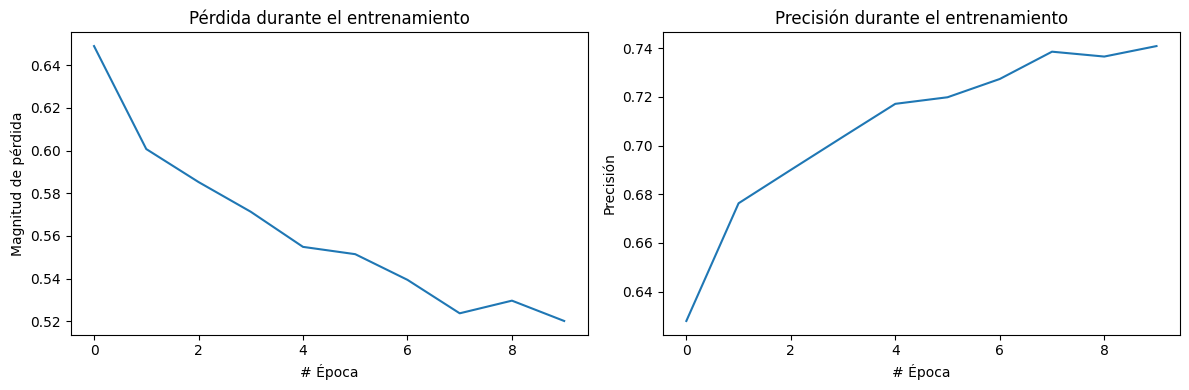

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.xlabel("# Época")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.title("Pérdida durante el entrenamiento")

plt.subplot(1, 2, 2)
plt.xlabel("# Época")
plt.ylabel("Precisión")
plt.plot(historial.history["accuracy"])
plt.title("Precisión durante el entrenamiento")

plt.tight_layout()
plt.show()

In [13]:
perdida, precision = modelo.evaluate(datos_pruebas)
print(f"\nPérdida en pruebas:   {perdida:.4f}")
print(f"Precisión en pruebas: {precision*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7115 - loss: 0.5718

Pérdida en pruebas:   0.5718
Precisión en pruebas: 71.15%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [14]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba  = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    predicciones     = modelo.predict(imagenes_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


In [15]:
def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = (
        arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    )
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    etiqueta_prediccion = np.argmax(arr_predicciones)
    color = 'blue' if etiqueta_prediccion == etiqueta_real else 'red'
    plt.xlabel(
        "{} {:2.0f}% ({})".format(
            nombres_clases[etiqueta_prediccion],
            100 * np.max(arr_predicciones),
            nombres_clases[etiqueta_real]
        ),
        color=color
    )

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks(range(2), ['Liviano', 'Pesado'], rotation=15)
    plt.yticks([])
    grafica = plt.bar(range(2), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)
    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

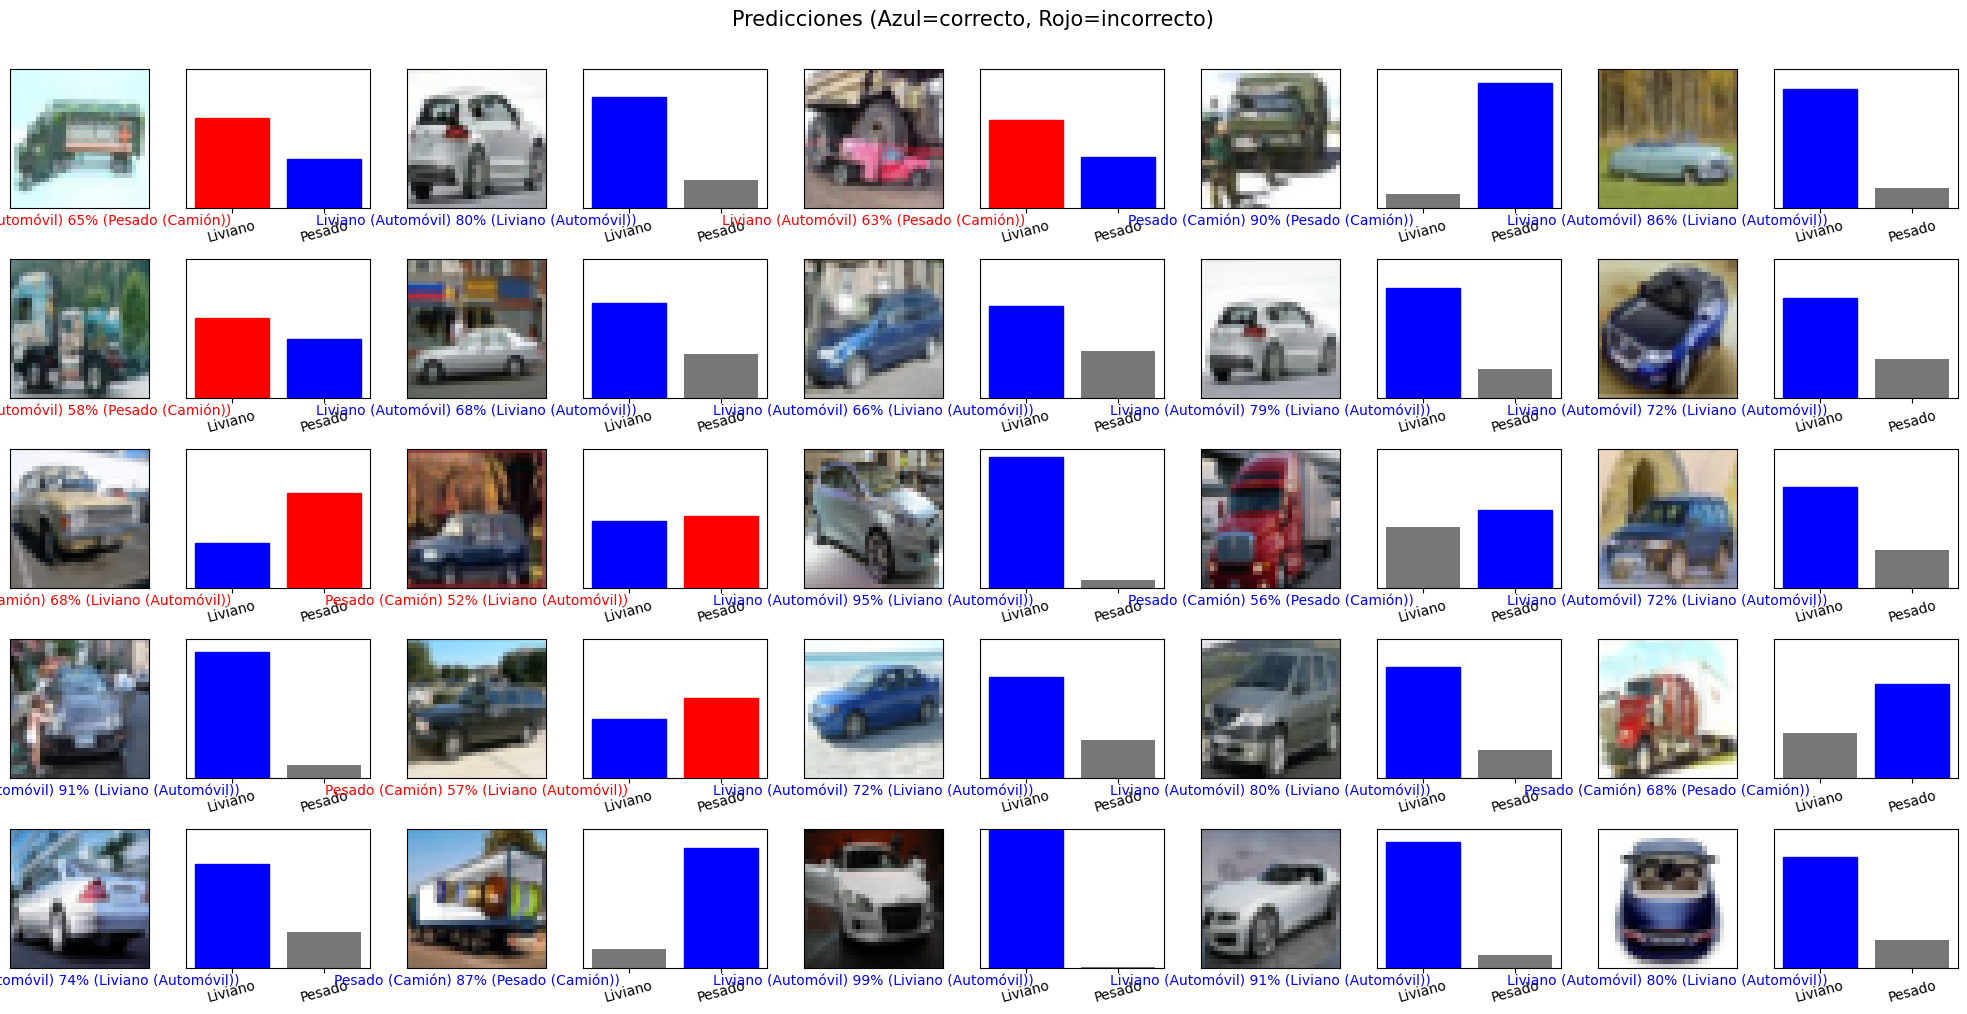

In [28]:
filas    = 5
columnas = 5
num_imagenes = filas * columnas

plt.figure(figsize=(2 * 2 * columnas, 2 * filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2 * columnas, 2 * i + 1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2 * columnas, 2 * i + 2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

plt.suptitle("Predicciones (Azul=correcto, Rojo=incorrecto)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Imagen real:     Liviano (Automóvil)
Predicción:      Liviano (Automóvil)
  Liviano: 66.3%
  Pesado:  33.7%


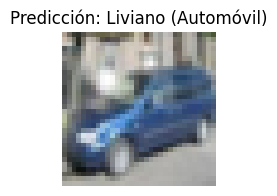

In [25]:
imagen_idx    = 7
imagen_suelta = imagenes_prueba[imagen_idx]
imagen_suelta = np.array([imagen_suelta])

prediccion = modelo.predict(imagen_suelta)

print("Imagen real:    ", nombres_clases[etiquetas_prueba[imagen_idx]])
print("Predicción:     ", nombres_clases[np.argmax(prediccion[0])])
print(f"  Liviano: {prediccion[0][0]*100:.1f}%")
print(f"  Pesado:  {prediccion[0][1]*100:.1f}%")

plt.figure(figsize=(2, 2))
plt.imshow(imagenes_prueba[imagen_idx])
plt.title(f"Predicción: {nombres_clases[np.argmax(prediccion[0])]}")
plt.axis('off')
plt.show()